# 📒 Day 41: Clustering - K-Means and DBSCAN

---
## 🎯 Objective

Understand the intuition and implementation of unsupervised clustering methods—K-Means and DBSCAN—on a real-world dataset. Learn to compare them, evaluate performance, and extract actionable insights from grouped data.

---

## 🧠 Introduction

In the real world, labels are expensive. Clustering allows us to make sense of unlabeled data by grouping data points with similar behavior. Whether you're segmenting customers, detecting anomalies, or compressing images—clustering is foundational in data science.

---

## 📂 Dataset Overview

**Use cases**:

- Customer segmentation
- Anomaly detection
- Image compression
- Market basket analysis

---

## 📦 **Dataset: Mall Customers Dataset**

We’ll use the *Mall Customers Dataset*, which includes customer information like age, income, and spending score. Perfect for understanding behavioral segmentation.

**Download dataset** from Kaggle:

🔗 Mall Customers Dataset

---

## 📥 Step 1: Import Libraries

---

In [20]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [3]:
#Load Dataset
df = pd.read_csv('Mall_Customers.csv')
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#### Here, we summarize data types, nulls, basic stats, and inspect key columns to identify features suitable for clustering.


# 🧹 Data Preprocessing
We will:

- Drop irrelevant or redundant features

- Handle missing values

- Normalize features (especially important for DBSCAN)

- Visualize feature distribution

---

## 🛠️ Implementation Plan

We will implement two clustering approaches:

**K-Means** — works well when clusters are globular and balanced.

**DBSCAN** — excels when clusters vary in shape and we expect noise.

---

In [4]:
#Select numerical feature only for clustering
features = df.select_dtypes(include=['int64', 'float64']).dropna(axis=1)

In [5]:
#Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

C:\Users\francis\Desktop\machinelearning_project\env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\francis\Desktop\machinelearning_project\env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\francis\Desktop\machinelearning_project\env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\francis\Desktop\machinelearning_project\env

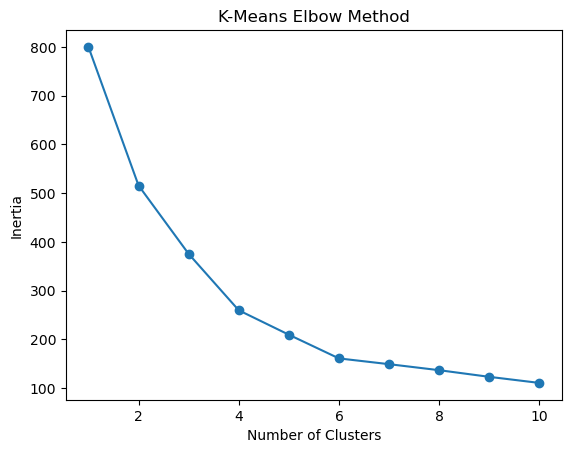

In [14]:
# K-Means Elbow Plot

inertia = []
for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('K-Means Elbow Method')
plt.show()

In [15]:
#Choose Optimal k
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

C:\Users\francis\Desktop\machinelearning_project\env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [16]:
#DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

## 📊 Model Evaluation

---

In [17]:
print("K-Means Silhouette Score:", silhouette_score(X_scaled, kmeans_labels))
print("DBSCAN Silhouette Score:", silhouette_score(X_scaled, dbscan_labels))

K-Means Silhouette Score: 0.4140456252637291
DBSCAN Silhouette Score: 0.17705955919038946


#### Silhouette score helps understand how well clusters are separated and cohesive. Higher is better (up to 1).


## 🎨 Visualization of Results

---

In [18]:
df['KMeans'] = kmeans_labels
df['DBSCAN'] = dbscan_labels

In [21]:
#Using firs 2 PCA Components for 2D Plotting

pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

df['PCA1'] = pca_components[:,0]
df['PCA2'] = pca_components[:,1]

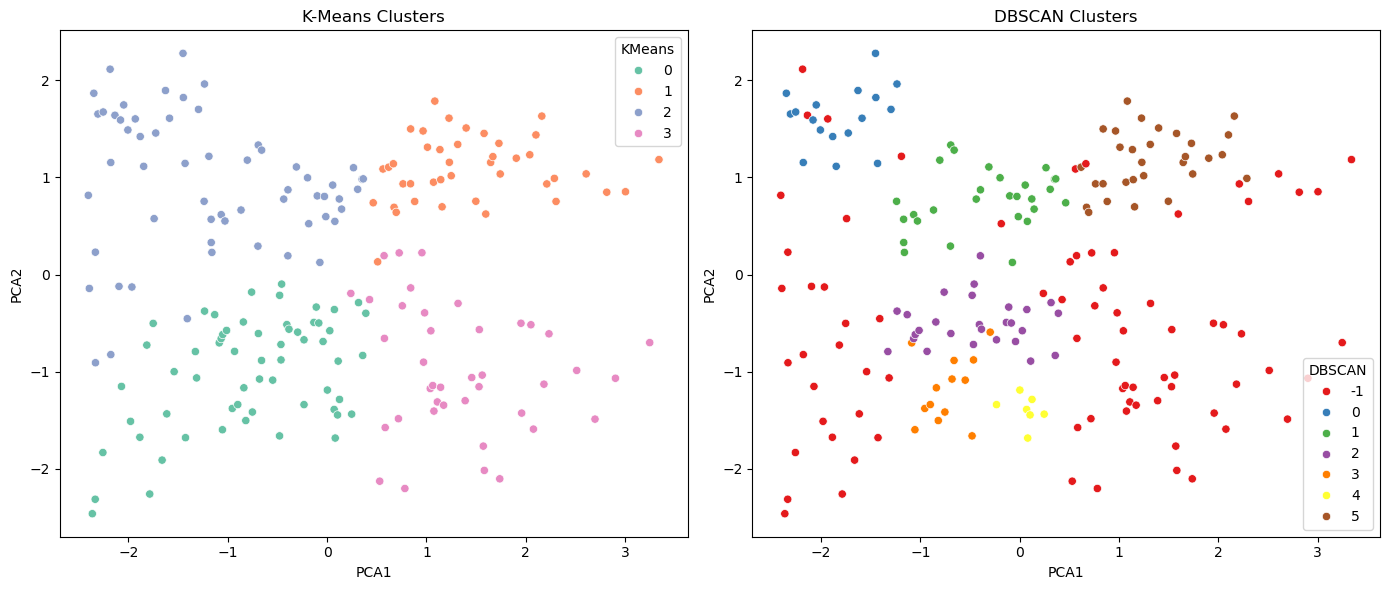

In [22]:
fig, ax = plt.subplots(1,2, figsize=(14,6))

sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='KMeans', palette='Set2', ax=ax[0])
ax[0].set_title('K-Means Clusters')

sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='DBSCAN', palette='Set1', ax=ax[1])
ax[1].set_title('DBSCAN Clusters')

plt.tight_layout()
plt.show()

## 🔍 Insights & Interpretation
Discuss how the clusters differ (e.g., in income, age, etc.)

Identify noise points from DBSCAN (cluster label -1)

Match clusters to potential business actions (e.g., targeted marketing)
